## Setup and load

Same cleaned dataset used everywhere else in this project - nothing new to clean here, since `Industry`, `DevType`, `Country`, and `AI_adopter` were already prepared in `01_cleaning.ipynb`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('survey_clean.csv')
baseline = df['AI_adopter'].mean()
print(f"Loaded {len(df):,} rows. Overall AI adoption baseline: {baseline:.1%}")

Loaded 49,191 rows. Overall AI adoption baseline: 33.1%


In [2]:
# One global style call configures every chart made after this point.
sns.set_theme(
    style="whitegrid",       # light background with horizontal gridlines only
    palette="Blues_d",        # a single-hue blue ramp -> matches "one sequential hue" best practice
    font="DejaVu Sans",
    rc={
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#898781",
        "ytick.color": "#0b0b0b",
        "grid.color": "#e1e0d9",
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
    },
)
print("seaborn theme set")

seaborn theme set


In [ ]:
def adoption_rate_chart(column, min_n, title, top_n=None, figsize_scale=0.42):
    """
    Build a seaborn/matplotlib horizontal bar chart of AI_adopter rate by `column`.

    column       : the groupby column, e.g. 'Industry', 'DevType', 'Country'
    min_n        : minimum respondents required for a group to be shown
                   (keeps a 3-person group from producing a meaningless 100% bar)
    title        : chart title
    top_n        : if set, only the top N groups by rate are shown (useful for Country,
                   which has 50+ eligible groups -- too many bars to read at once)
    """
    g = df.groupby(column)['AI_adopter'].agg(['mean', 'count']).rename(
        columns={'mean': 'rate', 'count': 'n'}
    )
    g = g[g['n'] >= min_n].sort_values('rate', ascending=False)
    if top_n:
        g = g.head(top_n)
    g = g.sort_values('rate')  # ascending for a horizontal bar chart (largest bar on top)

    fig_h = max(3.2, figsize_scale * len(g) + 1.4)
    fig, ax = plt.subplots(figsize=(8.5, fig_h))

    # sns.barplot draws the bars; we still reach into matplotlib (ax) for everything
    # seaborn doesn't have a dedicated helper for (reference line, direct labels, etc.)
    sns.barplot(
        x=g['rate'], y=g.index, ax=ax,
        color="#2a78d6", orient='h', width=0.62,
    )

    # baseline reference line -- plain matplotlib, seaborn has no equivalent
    ax.axvline(baseline, color="#e34948", linewidth=1.5, linestyle=(0, (4, 3)), zorder=4)
    ax.text(baseline, -0.7, f" baseline {baseline:.1%}", color="#e34948",
            fontsize=9, fontweight="bold", va="top")

    # direct value labels on each bar
    for i, (rate, n) in enumerate(zip(g['rate'], g['n'])):
        ax.text(rate + 0.008, i, f"{rate:.1%}", va="center", fontsize=8.5, color="#0b0b0b")

    ax.set_xlim(0, max(g['rate'].max(), baseline) * 1.18)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel("AI model adoption rate")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left", pad=14)
    sns.despine(ax=ax, left=True)  # seaborn helper: removes the top/right/left spines cleanly

    fig.tight_layout()
    return fig, ax, g

print("adoption_rate_chart() defined")

adoption_rate_chart() defined


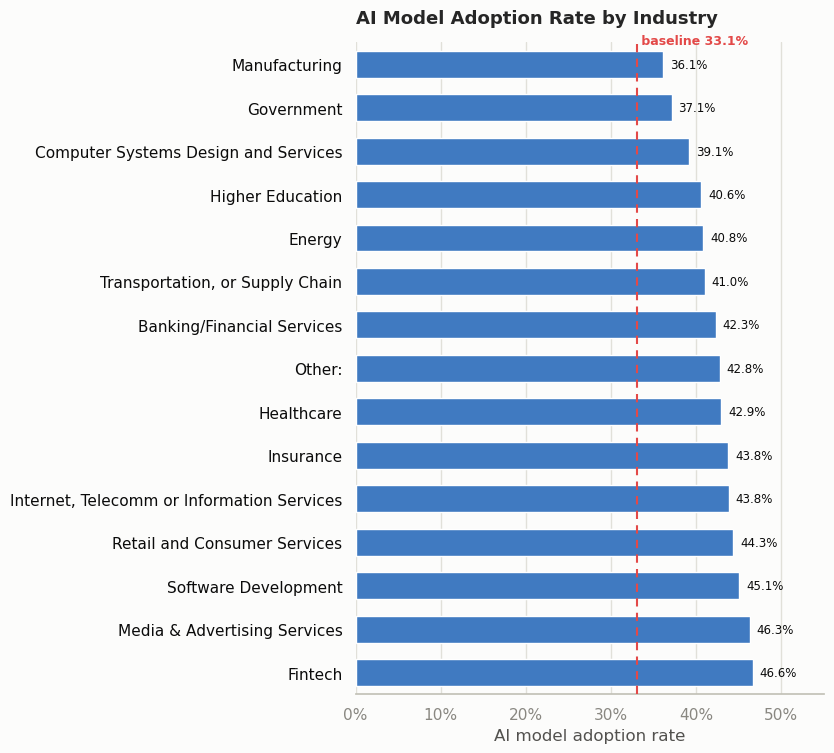

In [4]:
fig, ax, g_industry = adoption_rate_chart('Industry', min_n=50, title='AI Model Adoption Rate by Industry')
fig.savefig('seaborn_adoption_by_industry.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

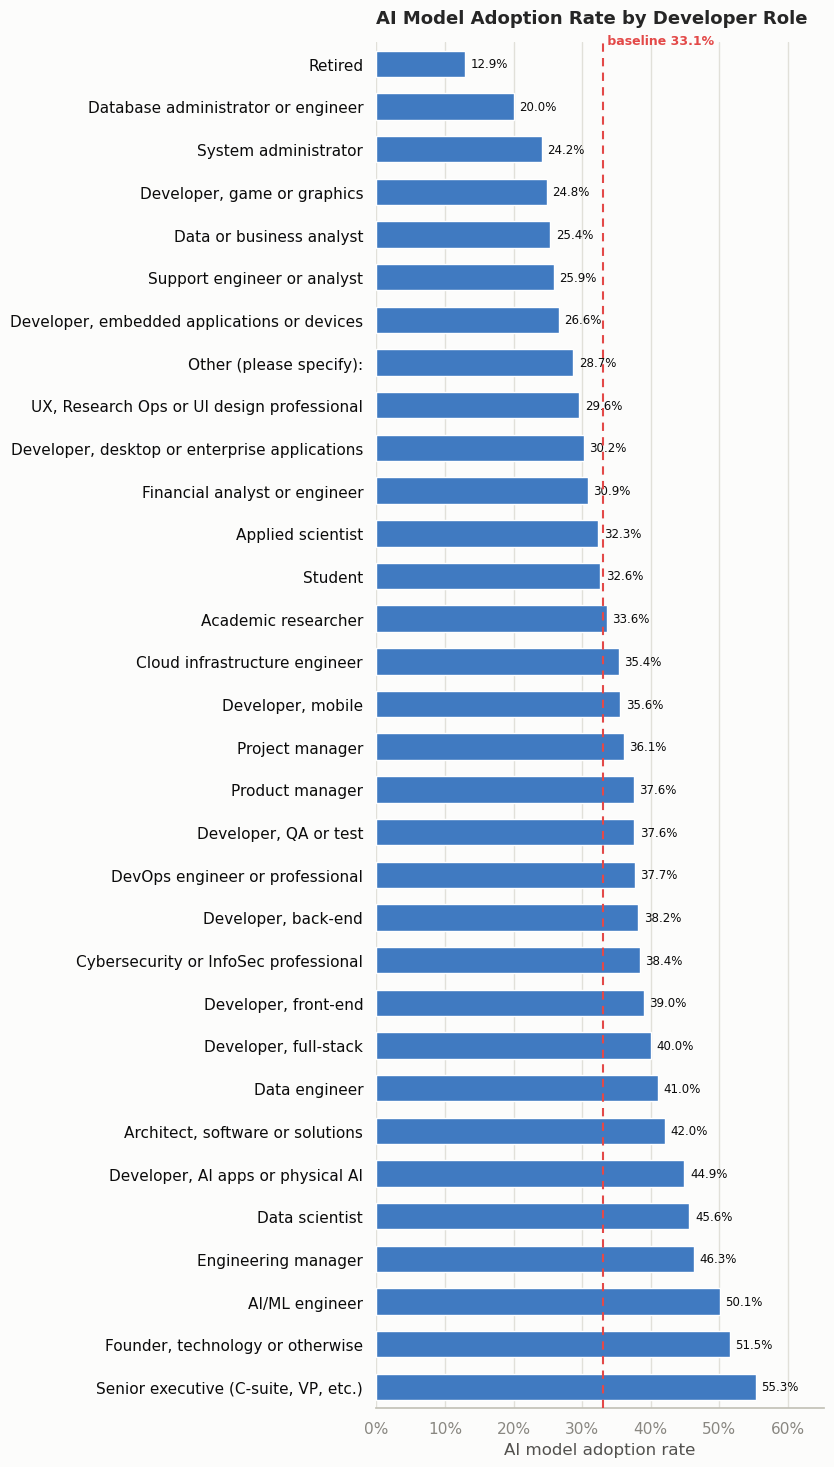

In [5]:
fig, ax, g_role = adoption_rate_chart('DevType', min_n=50, title='AI Model Adoption Rate by Developer Role')
fig.savefig('seaborn_adoption_by_role.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

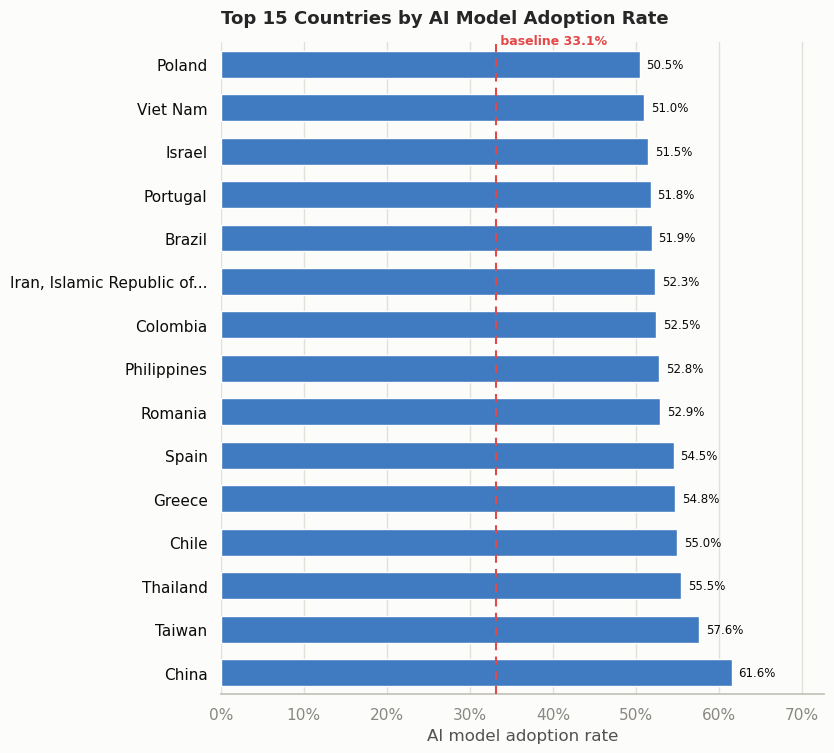

In [6]:
fig, ax, g_country = adoption_rate_chart('Country', min_n=100, top_n=15, title='Top 15 Countries by AI Model Adoption Rate')
fig.savefig('seaborn_adoption_by_country.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()